# Linear Regression



    Linear Regression is the simplest algorithm in machine learning.  
    In this notebook we will use Linear Regression as well as Random Forest Regressor and XGBoost Regressor


## Imports

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


### Data
In this exercise, we'll create a predictor of a house's price.  
Since it is a continuous variable, this is a **regression** problem.  
We are going to use the USA_Housing dataset, which contains the following columns:

        'Avg. Area Income': Average income of residents of the area where the house is located.
        'Avg. Area House Age': Avg Age of Houses in the same area
        'Avg. Area Number of Rooms': Average Number of Rooms for Houses in the same area
        'Avg. Area Number of Bedrooms': Average Number of Bedrooms for Houses in the same area
        'Area Population': Population of the area where the house is located
        'Price': Price at which the house was sold
        'Address': Address for the house



In [ ]:
df = pd.read_csv('../datasets/USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


## Exploratory Data Analysis (EDA)

In [ ]:
#  get a quick overview of the data structure, including data types and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


The initial inspection helped understand the dataset's basic structure and identify potential data quality issues (e.g., missing values, incorrect data types).


In [ ]:
# get statistics (count, mean, standard deviation, min, quartiles, max) for numerical features.
# It helps understanding the distribution and range of numerical features, identify potential outliers, and get a sense of the central tendency and variability of the data.

df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [ ]:
# Checking for missing values in the dataset
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

There are no missing values in this dataset.  
The absence of missing values simplifies the preprocessing phase

In [ ]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [ ]:
# Columns renaming for easier handling!

df.rename(columns={"Avg. Area Income":"Income"
                   , 'Avg. Area House Age':"Age"
                   , 'Avg. Area Number of Rooms':"Rooms"
                   , 'Avg. Area Number of Bedrooms':"Bedrooms"
                   , 'Area Population':"Population"}
          , inplace=True)

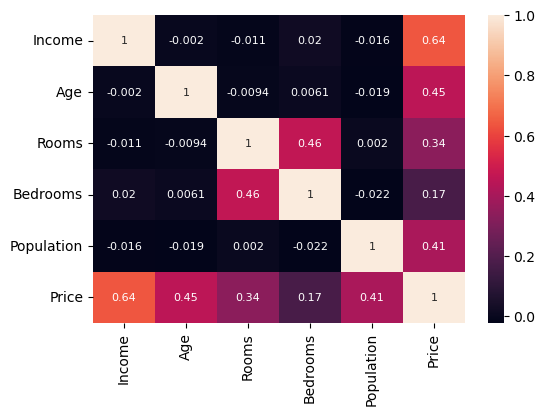

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, annot_kws={"size": 8})
plt.show()

The heatmap shows the linear relationships between numerical features and the target variable ('price').

'income' shows a strong positive correlation with 'price', indicating that higher incomes tend to be associated with higher prices.

This step is vital for feature selection and understanding which features are most likely to influence the target variable.

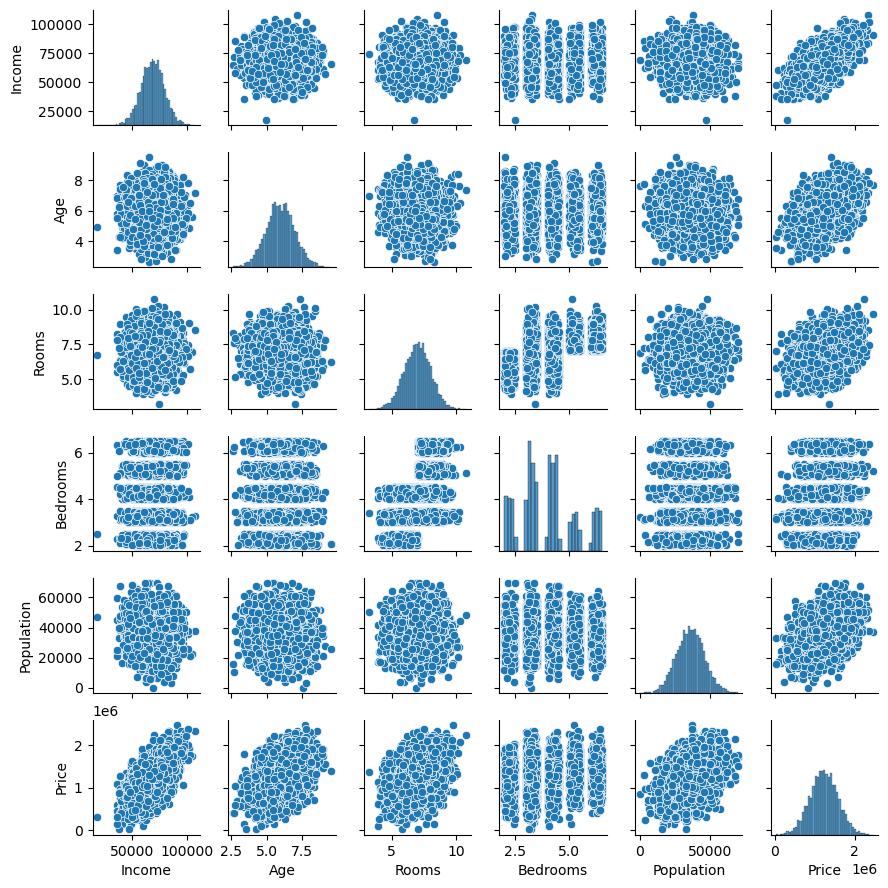

In [ ]:
# Visualization
sns.pairplot(df, height=1.5, aspect=1)
plt.show()

**Conclusion:**

Histograms reveal the distribution of each feature, identifying skewness or multimodality.

Scatter plots confirm the linear relationships observed in the correlation matrix and highlight potential outliers.

Visualizations are essential for gaining insights into the data's characteristics and identifying patterns or anomalies.


<Figure size 500x300 with 0 Axes>

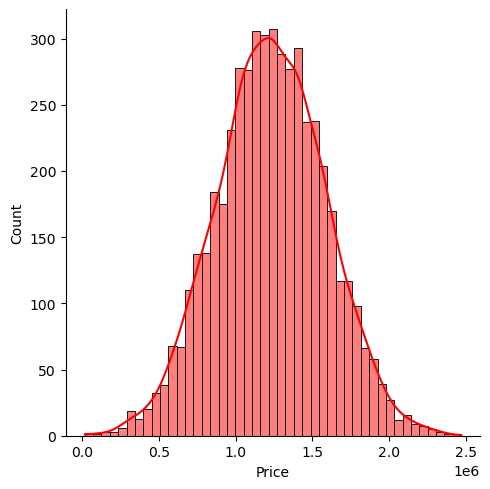

In [ ]:
plt.figure(figsize=(5,3))

sns.displot(data=df.Price, kde=True, color='red', edgecolor='black')
plt.show()

**Overall EDA Summary:**

The EDA provides a solid foundation for building regression models.

The dataset is relatively clean, with no missing values.

There is a Strong linear relationship between Income and Price, and moderate relationships between Age and Price and between Population and Price.

Visualizations confirm the findings from descriptive statistics and correlation analysis.

The EDA highlights the importance of feature selection and potential feature engineering opportunities.

In [ ]:
df.columns

Index(['Income', 'Age', 'Rooms', 'Bedrooms', 'Population', 'Price', 'Address'], dtype='object')

## Pre-Processing

In [ ]:
#Scaling the attributes using normal scaler
from sklearn.preprocessing import StandardScaler
standardScaler = StandardScaler()
columns_to_scale = ['Income', 'Age', 'Rooms', 'Bedrooms', 'Population']
df[columns_to_scale] = standardScaler.fit_transform(df[columns_to_scale])
df

,Income,Age,Rooms,Bedrooms,Population,Price,Address
0,1.028660,-0.296927,0.021274,0.088062,-1.317599,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,1.000808,0.025902,-0.255506,-0.722301,0.403999,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,-0.684629,-0.112303,1.516243,0.930840,0.072410,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,-0.491499,1.221572,-1.393077,-0.584540,-0.186734,1.260617e+06,USS Barnett\nFPO AP 44820
4,-0.807073,-0.944834,0.846742,0.201513,-0.988387,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,-0.752109,1.869297,-0.845588,-0.422467,-1.342732,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,0.929740,1.030822,-0.408686,0.031337,-1.062747,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,-0.487235,1.284470,-2.170269,-1.500251,-0.291937,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,-0.054592,-0.446694,0.141541,1.182053,0.651116,1.198657e+06,USS Wallace\nFPO AE 73316


In [ ]:
#Let's now begin to train our regression model! We will need to first split up our data 
#into an X array that contains the features to train on, and a y array with the target 
#variable, in this case, the Price column. We will toss out the Address column because it 
#only has text info that the linear regression model can't use.

X = df.drop(['Price','Address'],axis=1)
y = df['Price']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Train

In [ ]:
from sklearn import metrics
from sklearn.model_selection import cross_val_score

def cross_val(model):
    pred = cross_val_score(model, X, y, cv=10)
    return pred.mean()
    
def evaluate(reais, previstos):
    mae = metrics.mean_absolute_error(reais, previstos)
    mse = metrics.mean_squared_error(reais, previstos)
    rmse = np.sqrt(metrics.mean_squared_error(reais, previstos))
    r2 = metrics.r2_score(reais, previstos)
    return mae, mse, rmse, r2

def print_evaluate(reais, previstos):  
    mae, mse, rmse, r2 = evaluate(reais, previstos)
    print('__________________________________')
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2:', r2)
    print('__________________________________')
    
results_df=pd.DataFrame(columns=['Model','MAE','MSE','RMSE','R2'])

,Model,MAE,MSE,RMSE,R2


In [ ]:
from time import time
from sklearn.model_selection import GridSearchCV

def assess (model):
    l = []
    #model.fit(X_train,y_train)
    y_true = y_test 
    y_pred = model.predict(X_test)# The predictions from the model
    
    mae=metrics.mean_absolute_error(y_true, y_pred)
    mse=metrics.mean_squared_error(y_true, y_pred)
    rmse=metrics.root_mean_squared_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print(str(model),mae,mse,rmse,r2)

    l.append(str(model))
    l.append(mae)
    l.append(mse)
    l.append(rmse)
    l.append(r2)

    results=np.array(l)

#    results=np.array([model,mae,mse,rmse,r2])
    results_df.loc[len(results_df)+1]=results
    return results

def grid_search(model, params):
    GSCV = GridSearchCV(estimator=model
                    ,param_grid=params
                    ,cv=5
                    ,n_jobs = -1
                    ,verbose = 2)
    start = time()
    GSCV.fit(X_train, y_train)
    grid_time = time() - start
    print("Grid time:", grid_time)
    print(GSCV.best_params_) 
    print(GSCV.best_score_)
    return GSCV.best_params_

### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)
assess(lr)

LinearRegression() 81135.56609336878 10068422551.40088 100341.52954485436 0.9146818498754016


array(['LinearRegression()', '81135.56609336878', '10068422551.40088',
       '100341.52954485436', '0.9146818498754016'], dtype='<U32')

#### Interpretar as previsões

Let's grab predictions off our test set and see how well it did!

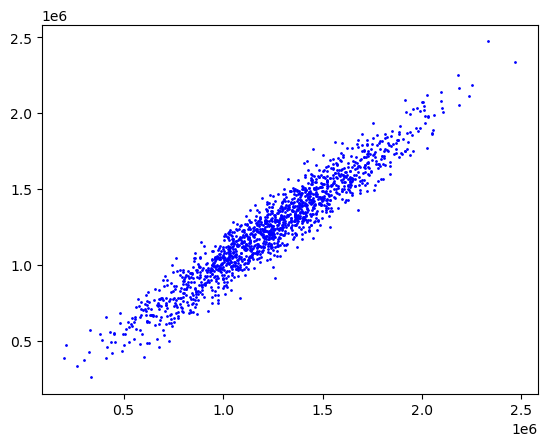

In [ ]:
lr_pred = lr.predict(X_test)

plt.scatter(y_test, lr_pred, color='blue', s=1)
plt.show()

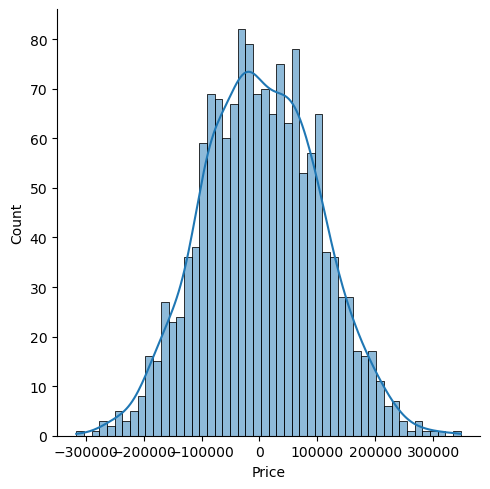

In [ ]:
sns.displot((y_test - lr_pred), bins=50, kde=True);
plt.show()

#### Avaliar

✔️ Regression Evaluation Metrics

Here are three common evaluation metrics for regression problems:

    Mean Absolute Error (MAE) is the mean of the absolute value of the errors.
    Mean Squared Error (MSE) is the mean of the squared errors.
    Root Mean Squared Error (RMSE) is the square root of the mean of the squared errors.

📌 Comparing these metrics:

    MAE is the easiest to understand, because it's the average error.
    MSE is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
    RMSE is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are loss functions, because we want to minimize them.

In [ ]:
print('Train set evaluation:')
train_pred = lr.predict(X_train)
print_evaluate(y_train, train_pred)

print('\n\nTest set evaluation:')
test_pred = lr.predict(X_test)
print_evaluate(y_test, test_pred)


Train set evaluation:
__________________________________
MAE: 81480.49973174892
MSE: 10287043161.197224
RMSE: 101425.06180031257
R2: 0.9192986579075526
__________________________________


Test set evaluation:
__________________________________
MAE: 81135.56609336878
MSE: 10068422551.40088
RMSE: 100341.52954485436
R2: 0.9146818498754016
__________________________________


### Random Forests

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=1000, random_state = 24)
rf_reg.fit(X_train, y_train)
results=assess(rf_reg)

RandomForestRegressor(n_estimators=1000, random_state=24) 94129.17052067288 14152551656.785036 118964.49746367626 0.8800736142394305


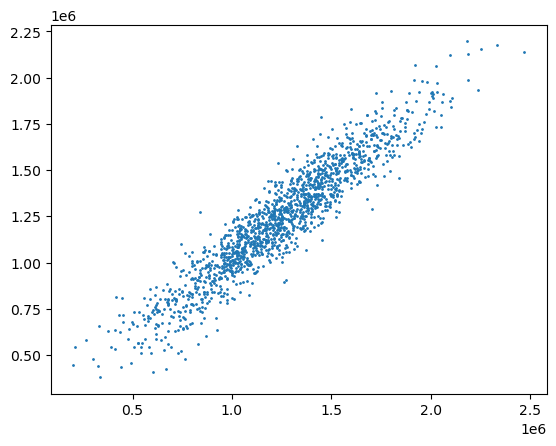

In [ ]:
rf_pred = rf_reg.predict(X_test)

plt.scatter(y_test, rf_pred, s=1)
plt.show()

In [ ]:
print('Train set evaluation:')
train_pred = rf_reg.predict(X_train)
print_evaluate(y_train, train_pred)

print('\n\nTest set evaluation:')
test_pred = rf_reg.predict(X_test)
print_evaluate(y_test, test_pred)

Train set evaluation:
__________________________________
MAE: 35382.35474859644
MSE: 1994171055.8338866
RMSE: 44656.14241998391
R2: 0.9843558272240225
__________________________________


Test set evaluation:
__________________________________
MAE: 94129.17052067288
MSE: 14152551656.785036
RMSE: 118964.49746367626
R2: 0.8800736142394305
__________________________________


#### Optimize RF

In [ ]:
rf_reg.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 1000,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 24,
 'verbose': 0,
 'warm_start': False}

In [ ]:
#Grid time: 13m

model = RandomForestRegressor(random_state = 24)
params = {
   'n_estimators': [1000, 1800],
   'max_features': ['sqrt', 'log2', None],
   'max_depth' : [None, 10, 20],
   'criterion' : ['poisson', 'squared_error'] 
    }

best_params = grid_search(model, params)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Grid time: 780.0216131210327
{'criterion': 'poisson', 'max_depth': 20, 'max_features': None, 'n_estimators': 1800}
0.8835457854944275


In [ ]:
# falta criar rf otimizada
# create a new RF
rf_reg_2 = RandomForestRegressor( random_state=24
                                ,n_estimators = 1000 #best_params['n_estimators']
                                ,max_features = 1.0 #best_params['max_features']
                                ,max_depth    = None
                                ,criterion    = 'squared_error'
                                )
rf_reg_2.fit(X_train, y_train)

print("Random Forest Regressor:")
rf_pred_2 = rf_reg_2.predict(X_test)
print_evaluate( y_test, rf_pred_2)

Random Forest Regressor:
__________________________________
MAE: 94129.17052067288
MSE: 14152551656.785036
RMSE: 118964.49746367626
R2: 0.8800736142394305
__________________________________


### XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost.sklearn import XGBRegressor
xgb=XGBRegressor()
xgb.fit(X_train,y_train)
results=assess(xgb)
xgb.get_params()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) 100098.94333935666 15812853401.025711 125749.16858979908 0.8660044914206281


{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

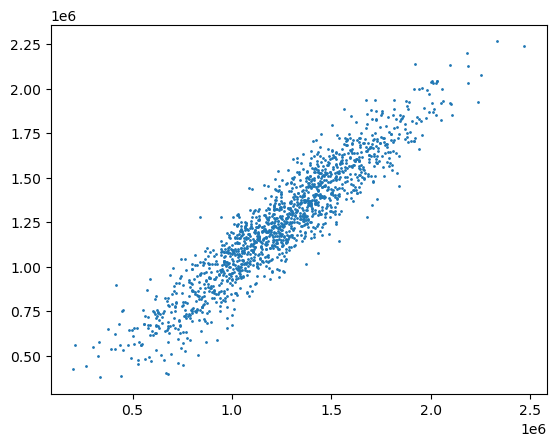

In [ ]:
xgb_pred = xgb.predict(X_test)

plt.scatter(y_test, xgb_pred, s=1)
plt.show()

In [ ]:
print('Train set evaluation:')
train_pred = xgb.predict(X_train)
print_evaluate(y_train, train_pred)

print('\n\nTest set evaluation:')
test_pred = xgb.predict(X_test)
print_evaluate(y_test, test_pred)

Train set evaluation:
__________________________________
MAE: 31629.427822810165
MSE: 1809884318.3986166
RMSE: 42542.73520119054
R2: 0.9858015475158322
__________________________________


Test set evaluation:
__________________________________
MAE: 100098.94333935666
MSE: 15812853401.025711
RMSE: 125749.16858979908
R2: 0.8660044914206281
__________________________________


## Results

In [ ]:
results_df

,Model,MAE,MSE,RMSE,R2
1,LinearRegression(),81135.56609336878,10068422551.40088,100341.52954485436,0.9146818498754016
2,"RandomForestRegressor(n_estimators=1000, rando...",94129.17052067288,14152551656.785036,118964.49746367626,0.8800736142394305
3,"RandomForestRegressor(n_estimators=1000, rando...",94129.17052067288,14152551656.785036,118964.49746367626,0.8800736142394305
4,"XGBRegressor(base_score=None, booster=None, ca...",100098.94333935666,15812853401.025711,125749.16858979908,0.8660044914206281
